# Key Efficiencies Comparison

This is the notebook to benchmark MD, SR and TPT, all over transmission distance. The asymptotic key rates are found as follows, where $m \geq 1$ is a free parameter for TPT and SR.

$$
K_\infty^\text{SR} = H(S_{1,\ldots,m}(X)) - \sum_{i \in m} h(e_\text{i, SR}) - \chi_{EB}
$$

$$
K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
$$

$$
K_\infty^\text{TPT} = p_\text{pass}(H(T(X)) - h(e_\text{TPT}) - \chi_{EB})
$$

Therefore, to plot these, we need to optimise each of the above key rates over $V_\text{mod}$ for a given $T(d) = 10^{-(\alpha d)/10}$ where $\alpha$ is the fibre loss coefficient, which we will say is 0.2 dB/km. For rigor, the optimisation problem becomes
$$
\max_{V_{\mathrm{mod}},\,\{\tau_i\}_{i=1}^M,\,\{g_{j,-},g_{j,+}\}_{j=-M}^M}
K_{\infty,\mathrm{TPT}}\Bigl(
    V_{\mathrm{mod}},\;
    \{\tau_{-M},\dots,\tau_{-1},0,\tau_{1},\dots,\tau_{M}\},\;
    \{g_{j,-},g_{j,+}\}_{j=-M}^M
    \;;\;T,\xi
\Bigr)
$$
where $g_{i,\pm} = 0 \;\; \forall i$ in the case of SR.

In [1]:
r"""
Here's the above markdown in a python comment so copilot etc can see it

# Key Efficiencies Comparison

This is the notebook to benchmark MD, SR and TPT, all over transmission distance. The asymptotic key rates are found as follows, where $m \geq 1$ is a free parameter for TPT and SR.

$$
K_\infty^\text{SR} = H(S_{1,\ldots,m}(X)) - \sum_{i \in m} h(e_\text{i, SR}) - \chi_{EB}
$$

$$
K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
$$

$$
K_\infty^\text{TPT} = p_\text{pass}(H(T(X)) - h(e_\text{TPT}) - \chi_{EB})
$$

Therefore, to plot these, we need to optimise each of the above key rates over $V_\text{mod}$ for a given $T(d) = 10^{-(\alpha d)/10}$ where $\alpha$ is the fibre loss coefficient, which we will say is 0.2 dB/km. For rigor, the optimisation problem becomes
$$
\max_{V_{\mathrm{mod}},\,\{\tau_i\}_{i=1}^M,\,\{g_{j,-},g_{j,+}\}_{j=-M}^M}
K_{\infty,\mathrm{TPT}}\Bigl(
    V_{\mathrm{mod}},\;
    \{\tau_{-M},\dots,\tau_{-1},0,\tau_{1},\dots,\tau_{M}\},\;
    \{g_{j,-},g_{j,+}\}_{j=-M}^M
    \;;\;T,\xi
\Bigr)
$$
where $g_{i,\pm} = 0 \;\; \forall i$ in the case of SR.

"""

"\nHere's the above markdown in a python comment so copilot etc can see it\n\n# Key Efficiencies Comparison\n\nThis is the notebook to benchmark MD, SR and TPT, all over transmission distance. The asymptotic key rates are found as follows, where $m \\geq 1$ is a free parameter for TPT and SR.\n\n$$\nK_\\infty^\\text{SR} = H(S_{1,\\ldots,m}(X)) - \\sum_{i \\in m} h(e_\\text{i, SR}) - \\chi_{EB}\n$$\n\n$$\nK_\\infty^\\text{MD} = H(U) - (1 - C_\\text{BIAWGNC}) - \\chi_{EB}\n$$\n\n$$\nK_\\infty^\\text{TPT} = p_\\text{pass}(H(T(X)) - h(e_\\text{TPT}) - \\chi_{EB})\n$$\n\nTherefore, to plot these, we need to optimise each of the above key rates over $V_\\text{mod}$ for a given $T(d) = 10^{-(\\alpha d)/10}$ where $\\alpha$ is the fibre loss coefficient, which we will say is 0.2 dB/km. For rigor, the optimisation problem becomes\n$$\n\\max_{V_{\\mathrm{mod}},\\,\\{\\tau_i\\}_{i=1}^M,\\,\\{g_{j,-},g_{j,+}\\}_{j=-M}^M}\nK_{\\infty,\\mathrm{TPT}}\\Bigl(\n    V_{\\mathrm{mod}},\\;\n    \\{\\tau_{-

In [2]:
import numpy as np
import importlib
from tqdm import tqdm
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from scipy.optimize import differential_evolution
from scipy.special import erfc  
import matplotlib.pyplot as plt

from guard_band_postselection import GBSR
importlib.reload(GBSR)

print("Libraries imported.")

Libraries imported.


## SR

In [3]:
# Global variables and functions
distances = np.linspace(0.001, 100, 50)
fibre_loss_coeff = 0.2 # In dB/km

_lambda = True

def T_from_d(d):
    # T(d) = 10^{-(\alpha d)/10}
    return np.power(10.0, -(fibre_loss_coeff * d) / 10.0)

In [4]:
# m1
m = 1

sr = GBSR.SR(m, 1.0, 1.0, 0.0, _lambda = True)

DW_key_rates = []
Is = []
chis = []

SR_m1_key_rates = []
SR_m1_error_rates = []
SR_m1_v_mods = []
SR_m1_leaked_informations = []

tau_arr = [-np.inf, 0.0, np.inf]
g_arr = [
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0]
]

for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Optimise v_mod for this distance
    def v_mod_objective_function(v_mod):
        sr.__init__(m, v_mod, transmittance, 0.0, _lambda = True)

        return -1.0 * sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)
    
    optimisation_return = minimize_scalar(v_mod_objective_function, bounds=(0.5, 10.0), method='bounded')

    SR_m1_v_mods.append(optimisation_return.x)
    SR_m1_key_rates.append(-1.0 * optimisation_return.fun)

    # Set optimal gbsr
    sr.__init__(m, SR_m1_v_mods[-1], transmittance, 0.0, _lambda = True)
    error_rates = sr.evaluate_error_rate(tau_arr, g_arr)
    SR_m1_error_rates.append(error_rates)
    SR_m1_leaked_informations.append(sr._evaluate_leaked_information())

    DW_key_rates.append(sr.devetak_winter)
    Is.append(sr.I_AB)
    chis.append(sr.gaussian_attack_holevo_information)

100%|██████████| 50/50 [00:02<00:00, 20.10it/s]


In [5]:
# m2
"""
m = 2

sr = GBSR.SR(m, 1.0, 1.0, 0.0, _lambda = _lambda)

SR_m2_key_rates = []
SR_m2_error_rates = []
SR_m2_v_mods = []
SR_m2_leaked_informations = []
SR_m2_ts = []

# No g_arr in this case
g_arr = [[0.0, 0.0]] * 5

# Define objective function
def m2_SR_objective_function(params, args):
    v_mod, t_1 = params
    transmittance = args

    tau_arr = [-np.inf, t_1, 0.0, -1.0 * t_1, np.inf]

    sr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)

    return -1.0 * sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)

# Loop over distances
for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Perform optimisation
    initial_guesses = [
        1.0, # v_mod
        norm.ppf(0.25) # t_1, 25th percentile
    ]

    bounds = [
        (0.01, 10.0), # v_mod
        (-5.0, -1e-6) # t_1
    ]

    optimisation_return = minimize(m2_SR_objective_function, initial_guesses, args=(transmittance,), bounds=bounds)

    optimal_v_mod, optimal_t_1 = optimisation_return.x
    optimal_t_3 = -1.0 * optimal_t_1

    tau_arr = [-np.inf, optimal_t_1, 0.0, optimal_t_3, np.inf]
    sr.__init__(m, optimal_v_mod, transmittance, 0.0, _lambda = _lambda)

    error_rates = sr.evaluate_error_rate(tau_arr, g_arr)
    SR_m2_error_rates.append(error_rates)
    SR_m2_key_rates.append(-1.0 * optimisation_return.fun)
    SR_m2_v_mods.append(optimal_v_mod)
    SR_m2_leaked_informations.append(sr._evaluate_leaked_information())
    SR_m2_ts.append(optimal_t_1)
"""

'\nm = 2\n\nsr = GBSR.SR(m, 1.0, 1.0, 0.0, _lambda = _lambda)\n\nSR_m2_key_rates = []\nSR_m2_error_rates = []\nSR_m2_v_mods = []\nSR_m2_leaked_informations = []\nSR_m2_ts = []\n\n# No g_arr in this case\ng_arr = [[0.0, 0.0]] * 5\n\n# Define objective function\ndef m2_SR_objective_function(params, args):\n    v_mod, t_1 = params\n    transmittance = args\n\n    tau_arr = [-np.inf, t_1, 0.0, -1.0 * t_1, np.inf]\n\n    sr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)\n\n    return -1.0 * sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)\n\n# Loop over distances\nfor d in tqdm(distances):\n    transmittance = T_from_d(d)\n\n    # Perform optimisation\n    initial_guesses = [\n        1.0, # v_mod\n        norm.ppf(0.25) # t_1, 25th percentile\n    ]\n\n    bounds = [\n        (0.01, 10.0), # v_mod\n        (-5.0, -1e-6) # t_1\n    ]\n\n    optimisation_return = minimize(m2_SR_objective_function, initial_guesses, args=(transmittance,), bounds=bounds)\n\n    optimal_v_mod, o

In [6]:
# -----------------  m = 3  -----------------------------------------------
"""
m = 3

sr = GBSR.SR(m, 1.0, 1.0, 0.0, _lambda = _lambda)

SR_m3_key_rates           = []
SR_m3_error_rates         = []
SR_m3_v_mods              = []
SR_m3_leaked_informations = []

SR_m3_t1s = []
SR_m3_t2s = []
SR_m3_t3s = []

# no guard bands → all zeros, length = 2^m + 1 = 9
g_arr = [[0.0, 0.0]] * 9


# objective to maximise the SR key rate (→ minimise its negative)
def m3_SR_objective_function(params, args):
    v_mod, t1, t2, t3 = params           # three negative thresholds
    transmittance     = args

    # enforce ordering t1 < t2 < t3 < 0 by sorting (cheaper than constraints)
    t_vals = np.sort([t1, t2, t3])       # ascending order, still negative
    t1, t2, t3 = t_vals

    tau_arr = [-np.inf, t1, t2, t3, 0.0, -t3, -t2, -t1, np.inf]

    sr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)   # re-initialise protocol

    return -sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)


# loop over the same distance grid
for d in tqdm(distances):
    transmittance = T_from_d(d)

    # ---------- optimisation ---------------------------------------------
    initial_guesses = [
        1.0,                     # v_mod
        norm.ppf(0.125),         # t1  ≈ −1.15   (12.5-th percentile)
        norm.ppf(0.25),          # t2  ≈ −0.674  (25-th percentile)
        norm.ppf(0.375)          # t3  ≈ −0.318  (37.5-th percentile)
    ]

    bounds = [
        (0.01, 10.0),            # v_mod
        (-5.0, -1e-6),           # t1
        (-5.0, -1e-6),           # t2
        (-5.0, -1e-6)            # t3
    ]

    opt = minimize(
        m3_SR_objective_function,
        initial_guesses,
        args=(transmittance,),
        bounds=bounds
    )

    optimal_v_mod, t1, t2, t3 = opt.x
    t_vals = np.sort([t1, t2, t3])       # keep them ordered
    t1, t2, t3 = t_vals

    tau_arr = [-np.inf, t1, t2, t3, 0.0, -t3, -t2, -t1, np.inf]

    # re-initialise once more with the optimum parameters
    sr.__init__(m, optimal_v_mod, transmittance, 0.0, _lambda = _lambda)

    # ---------- bookkeeping ---------------------------------------------
    error_rates = sr.evaluate_error_rate(tau_arr, g_arr)   # vector (e1,e2,e3)

    SR_m3_error_rates.append(error_rates)
    SR_m3_key_rates.append(-opt.fun)
    SR_m3_v_mods.append(optimal_v_mod)
    SR_m3_leaked_informations.append(sr._evaluate_leaked_information())

    SR_m3_t1s.append(t1)
    SR_m3_t2s.append(t2)
    SR_m3_t3s.append(t3)
"""

'\nm = 3\n\nsr = GBSR.SR(m, 1.0, 1.0, 0.0, _lambda = _lambda)\n\nSR_m3_key_rates           = []\nSR_m3_error_rates         = []\nSR_m3_v_mods              = []\nSR_m3_leaked_informations = []\n\nSR_m3_t1s = []\nSR_m3_t2s = []\nSR_m3_t3s = []\n\n# no guard bands → all zeros, length = 2^m + 1 = 9\ng_arr = [[0.0, 0.0]] * 9\n\n\n# objective to maximise the SR key rate (→ minimise its negative)\ndef m3_SR_objective_function(params, args):\n    v_mod, t1, t2, t3 = params           # three negative thresholds\n    transmittance     = args\n\n    # enforce ordering t1 < t2 < t3 < 0 by sorting (cheaper than constraints)\n    t_vals = np.sort([t1, t2, t3])       # ascending order, still negative\n    t1, t2, t3 = t_vals\n\n    tau_arr = [-np.inf, t1, t2, t3, 0.0, -t3, -t2, -t1, np.inf]\n\n    sr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)   # re-initialise protocol\n\n    return -sr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)\n\n\n# loop over the same distance grid\nfor d i

In [7]:
"""
plt.figure(figsize=(8, 5))
plt.plot(distances, SR_m1_key_rates, label='SR m=1')
plt.plot(distances, SR_m2_key_rates, label='SR m=2')
plt.plot(distances, SR_m3_key_rates, label='SR m=3')
plt.xlabel('Distance (km)')
plt.ylabel('Key Efficiency (bits/pulse)')
plt.title(r'Asymptotic ($\beta = 1$) SR Key Rates vs Distance for $m \in \{1,2,3\}$')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()
"""

"\nplt.figure(figsize=(8, 5))\nplt.plot(distances, SR_m1_key_rates, label='SR m=1')\nplt.plot(distances, SR_m2_key_rates, label='SR m=2')\nplt.plot(distances, SR_m3_key_rates, label='SR m=3')\nplt.xlabel('Distance (km)')\nplt.ylabel('Key Efficiency (bits/pulse)')\nplt.title(r'Asymptotic ($\x08eta = 1$) SR Key Rates vs Distance for $m \\in \\{1,2,3\\}$')\nplt.yscale('log')\nplt.legend()\nplt.grid(True, which='both', ls='--')\nplt.show()\n"

## TPT

In [8]:
# m1
"""
m = 1

gbsr = GBSR.GBSR(m, 1.0, 1.0, 0.0, _lambda = _lambda)

TPT_m1_key_rates = []
TPT_m1_error_rates = []
TPT_m1_v_mods = []
TPT_m1_gs = []
TPT_m1_leaked_informations = []

tau_arr = [-np.inf, 0.0, np.inf]

def TPT_m1_objective_function(params, args):
    v_mod, g = params
    transmittance = args

    gbsr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)    

    g_arr = [
        [0.0, 0.0],
        [g, g],
        [0.0, 0.0]
    ]

    return -1.0 * gbsr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)


for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Perform optimisation
    initial_guesss = [
        1.0, # v_mod
        0.1 # g
    ]

    bounds = [
        (0.01, 3.0), # v_mod
        (0.0, 5.0)
    ]

    optimisation_return = minimize(TPT_m1_objective_function, initial_guesss, args=(transmittance,), bounds=bounds)

    optimal_v_mod, optimal_g = optimisation_return.x
    g_arr = [
        [0.0, 0.0],
        [optimal_g, optimal_g],
        [0.0, 0.0]
    ]

    gbsr.__init__(m, optimal_v_mod, transmittance, 0.0, _lambda = _lambda)

    error_rate = gbsr.evaluate_error_rate(tau_arr, g_arr)
    TPT_m1_error_rates.append(error_rate)
    TPT_m1_key_rates.append(-1.0 * optimisation_return.fun)
    TPT_m1_v_mods.append(optimal_v_mod)
    TPT_m1_gs.append(optimal_g)
    TPT_m1_leaked_informations.append(gbsr._evaluate_leaked_information(error_rate))
"""

m = 1

gbsr = GBSR.GBSR(m, 1.0, 1.0, 0.0, _lambda = _lambda)

TPT_m1_key_rates = []
TPT_m1_error_rates = []
TPT_m1_v_mods = []
TPT_m1_gs = []
TPT_m1_leaked_informations = []
TPT_m1_p_passes = []

tau_arr = [-np.inf, 0.0, np.inf]

def TPT_m1_objective_function_g_only(g, args):
    v_mod, transmittance = args
    gbsr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)

    # Ensure g is a scalar
    g_scalar = float(np.squeeze(g))

    g_arr = [
        [0.0, 0.0],
        [g_scalar, g_scalar],
        [0.0, 0.0]
    ]

    return -1.0 * gbsr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)

for idx, d in enumerate(tqdm(distances)):
    transmittance = T_from_d(d)
    v_mod = SR_m1_v_mods[idx]

    initial_guess = [0.1]  # g
    bounds = [(0.0, 1.1)]  # g

    optimisation_return = minimize(
        TPT_m1_objective_function_g_only,
        initial_guess,
        args=([v_mod, transmittance],),
        bounds=bounds
    )

    optimal_g = optimisation_return.x[0]
    g_arr = [
        [0.0, 0.0],
        [optimal_g, optimal_g],
        [0.0, 0.0]
    ]

    gbsr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)

    error_rate = gbsr.evaluate_error_rate(tau_arr, g_arr)
    TPT_m1_error_rates.append(error_rate)
    TPT_m1_key_rates.append(-1.0 * optimisation_return.fun)
    TPT_m1_v_mods.append(v_mod)
    TPT_m1_gs.append(optimal_g)
    TPT_m1_leaked_informations.append(gbsr._evaluate_leaked_information(error_rate))
    TPT_m1_p_passes.append(gbsr.evaluate_p_pass(tau_arr, g_arr))



100%|██████████| 50/50 [00:01<00:00, 27.80it/s]


In [9]:
# %%  TPT (GBSR)  m = 2  – optimise g1m, g1p, g2  (Vmod & t1 fixed from SR-m2)
"""
m = 2
gbsr = GBSR.GBSR(m, 1.0, 1.0, 0.0, _lambda = _lambda)

TPT_m2_key_rates           = []
TPT_m2_error_rates         = []
TPT_m2_v_mods              = SR_m2_v_mods        # aliases
TPT_m2_t1s                 = SR_m2_ts
TPT_m2_gs                  = []                  # (g1m, g1p, g2)
TPT_m2_leaked_informations = []

# -------- objective used by scipy.minimize --------------------------------
def TPT_m2_objective_function(params, args):
    g1m, g1p, g2              = params
    v_mod, t1, transmittance  = args

    tau_arr = [-np.inf, t1, 0.0, -t1, np.inf]
    g_arr   = [[0.0, 0.0],
               [g1m, g1p],
               [g2,  g2 ],
               [g1p, g1m],          # symmetry
               [0.0, 0.0]]

    gbsr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)
    return -gbsr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)


# -------- inequality constraints: keep slack in both finite intervals -----
def make_constraints(t1):
    return [
        {
            'type': 'ineq',         # a ≥ 1e-9
            'fun': lambda g: (0.0 - g[2]) - (t1 + g[1]) - 1e-9
        },
        {
            'type': 'ineq',         # b ≥ 1e-9
            'fun': lambda g: ((-t1) - (-g[1])) - (0.0 + (-g[2])) - 1e-9
        }
    ]


# -------- warm-start initial guess ----------------------------------------
current_guess = np.array([0.1, 0.1, 0.1])   # g1m, g1p, g2

for idx, d in enumerate(tqdm(distances, desc="TPT m=2 (g-optim)")):
    trans  = T_from_d(d)
    v_fix  = SR_m2_v_mods[idx]
    t1_fix = float(min(SR_m2_ts[idx], -1e-6))   # make sure strictly negative

    opt = minimize(
        TPT_m2_objective_function,
        current_guess,
        args=((v_fix, t1_fix, trans),),
        bounds=[(0.0, 5.0)] * 3,
        constraints=make_constraints(t1_fix),
        method='SLSQP',
        options={'ftol': 1e-9, 'maxiter': 300}
    )

    if not opt.success:
        print(f"Warning: optimiser at d={d:.2f} km –", opt.message)

    g1m_opt, g1p_opt, g2_opt = opt.x
    current_guess = opt.x                         # warm-start for next d
    TPT_m2_gs.append(tuple(opt.x))

    # ----- evaluate & store results --------------------------------------
    tau_arr = [-np.inf, t1_fix, 0.0, -t1_fix, np.inf]
    g_arr   = [[0.0, 0.0],
               [g1m_opt, g1p_opt],
               [g2_opt,  g2_opt],
               [g1p_opt, g1m_opt],
               [0.0, 0.0]]

    gbsr.__init__(m, v_fix, trans, 0.0, _lambda = _lambda)
    err_vec = gbsr.evaluate_error_rate(tau_arr, g_arr)

    TPT_m2_key_rates.append(-opt.fun)
    TPT_m2_error_rates.append(err_vec)
    TPT_m2_leaked_informations.append(gbsr._evaluate_leaked_information(err_vec))
"""

'\nm = 2\ngbsr = GBSR.GBSR(m, 1.0, 1.0, 0.0, _lambda = _lambda)\n\nTPT_m2_key_rates           = []\nTPT_m2_error_rates         = []\nTPT_m2_v_mods              = SR_m2_v_mods        # aliases\nTPT_m2_t1s                 = SR_m2_ts\nTPT_m2_gs                  = []                  # (g1m, g1p, g2)\nTPT_m2_leaked_informations = []\n\n# -------- objective used by scipy.minimize --------------------------------\ndef TPT_m2_objective_function(params, args):\n    g1m, g1p, g2              = params\n    v_mod, t1, transmittance  = args\n\n    tau_arr = [-np.inf, t1, 0.0, -t1, np.inf]\n    g_arr   = [[0.0, 0.0],\n               [g1m, g1p],\n               [g2,  g2 ],\n               [g1p, g1m],          # symmetry\n               [0.0, 0.0]]\n\n    gbsr.__init__(m, v_mod, transmittance, 0.0, _lambda = _lambda)\n    return -gbsr.evaluate_key_rate_in_bits_per_pulse(tau_arr, g_arr)\n\n\n# -------- inequality constraints: keep slack in both finite intervals -----\ndef make_constraints(t1):\n    re

In [10]:
"""

plt.figure(figsize=(8, 5))
plt.plot(distances, TPT_m1_key_rates, label='TPT m=1')
plt.plot(distances, TPT_m2_key_rates, label='TPT m=2')
plt.xlabel('Distance (km)')
plt.ylabel('Key Efficiency (bits/pulse)')
plt.title(r'TPT Key Rates vs Distance for $m \in \{1,2\}$')
# plt.yscale('log')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

"""

"\n\nplt.figure(figsize=(8, 5))\nplt.plot(distances, TPT_m1_key_rates, label='TPT m=1')\nplt.plot(distances, TPT_m2_key_rates, label='TPT m=2')\nplt.xlabel('Distance (km)')\nplt.ylabel('Key Efficiency (bits/pulse)')\nplt.title(r'TPT Key Rates vs Distance for $m \\in \\{1,2\\}$')\n# plt.yscale('log')\nplt.legend()\nplt.grid(True, which='both', ls='--')\nplt.show()\n\n"

# MD

In [11]:
gbsr = GBSR.GBSR(1, 1.0, 1.0, 0.0, _lambda = _lambda)

MD_key_rates = []
MD_v_mods = SR_m1_v_mods  # Use SR_m1 v_mods directly
MD_leaked_informations = []

# This has been checked against Jouguet-2011 table 1 for correctness
def C_biawgn(SNR):
    if SNR <= 0:
        return 0.0
    def integrand(z):
        pdf = norm.pdf(z)
        log2t = np.log1p(np.exp(-2*np.sqrt(SNR)*z - 2*SNR)) / np.log(2)
        return pdf * log2t
    res, _ = quad(integrand, -10, 10, epsabs=1e-10, epsrel=1e-10)
    return 1 - res

def MD_lambda_model(distance):
    if distance < 0:
        distance = 0
    # Use an exponential approach: beta = 0.95 - A * exp(-k * distance)
    # Choose A = 0.35 (0.95 - 0.6) and set k to make it close to 0.95 at 30 km
    A = 0.1
    k = np.log(A / 0.01) / 30  # Ensure beta is within 0.01 of 0.95 by 30 km
    beta = 0.995 - A * np.exp(-k * distance)
    return (1.0 / beta) - 1.0

for d, v_mod in zip(distances, SR_m1_v_mods):
    transmittance = T_from_d(d)

    # Initialize gbsr with the given v_mod and transmittance
    gbsr.__init__(1, v_mod, transmittance, 0.0, _lambda = _lambda)

    # Evaluate key rate terms
    bits_sent = 1.0
    leaked_information = (1.0 + MD_lambda_model(d)) * (1.0 - C_biawgn(gbsr.SNR))
    holevo_information = gbsr.gaussian_attack_holevo_information

    # Key rate
    K = bits_sent - leaked_information - holevo_information

    # Append results for plotting
    MD_key_rates.append(K)
    MD_leaked_informations.append(C_biawgn(gbsr.SNR))

"""
gbsr = GBSR.GBSR(1, 1.0, 1.0, 0.0, _lambda = _lambda)

MD_key_rates = []
MD_v_mods = []
MD_leaked_informations = []

# This has been checked against Jouguet-2011 table 1 for correctness
def C_biawgn(SNR):
    if SNR <= 0:
        return 0.0
    def integrand(z):
        pdf = norm.pdf(z)
        log2t = np.log1p(np.exp(-2*np.sqrt(SNR)*z - 2*SNR)) / np.log(2)
        return pdf * log2t
    res, _ = quad(integrand, -10, 10, epsabs=1e-10, epsrel=1e-10)
    return 1 - res

def MD_lambda_model(distance):
    if distance < 0:
        distance = 0
    # Use an exponential approach: beta = 0.95 - A * exp(-k * distance)
    # Choose A = 0.35 (0.95 - 0.6) and set k to make it close to 0.95 at 30 km
    A = 0.1
    k = np.log(A / 0.01) / 30  # Ensure beta is within 0.01 of 0.95 by 30 km
    beta = 0.999 - A * np.exp(-k * distance)
    return (1.0 / beta) - 1.0


def MD_objective_function(variables, transmittance, d):
    # K_\infty^\text{MD} = H(U) - (1 - C_\text{BIAWGNC}) - \chi_{EB}
    (v_mod,) = variables

    # Only used to calculate Holevo information in this case.
    gbsr.__init__(1, v_mod, transmittance, 0.0, _lambda = 0.011)

    # Evaluate key rate terms
    bits_sent = 1.0
    leaked_information = (1.0 + MD_lambda_model(d)) * (1.0 - C_biawgn(gbsr.SNR))
    holevo_information = gbsr.gaussian_attack_holevo_information

    # Key rate
    K = bits_sent - leaked_information - holevo_information

    return -1.0 * K

for d in tqdm(distances):
    transmittance = T_from_d(d)

    # Optimise v_mod
    optimisation_return = minimize(
        MD_objective_function,
        (0.5,),
        args=(transmittance, d),
        bounds = [(1.0, 3.0)],
    )

    # Unpack optimisation return for plotting
    MD_v_mods.append(optimisation_return.x[0])
    MD_key_rates.append(-optimisation_return.fun)

    # Initialize gbsr with the optimal v_mod and transmittance
    gbsr.__init__(1, optimisation_return.x[0], transmittance, 0.0, _lambda = _lambda)
    
    # Append the leaked information using the SNR from the initialized gbsr
    MD_leaked_informations.append(C_biawgn(gbsr.SNR))
"""


'\ngbsr = GBSR.GBSR(1, 1.0, 1.0, 0.0, _lambda = _lambda)\n\nMD_key_rates = []\nMD_v_mods = []\nMD_leaked_informations = []\n\n# This has been checked against Jouguet-2011 table 1 for correctness\ndef C_biawgn(SNR):\n    if SNR <= 0:\n        return 0.0\n    def integrand(z):\n        pdf = norm.pdf(z)\n        log2t = np.log1p(np.exp(-2*np.sqrt(SNR)*z - 2*SNR)) / np.log(2)\n        return pdf * log2t\n    res, _ = quad(integrand, -10, 10, epsabs=1e-10, epsrel=1e-10)\n    return 1 - res\n\ndef MD_lambda_model(distance):\n    if distance < 0:\n        distance = 0\n    # Use an exponential approach: beta = 0.95 - A * exp(-k * distance)\n    # Choose A = 0.35 (0.95 - 0.6) and set k to make it close to 0.95 at 30 km\n    A = 0.1\n    k = np.log(A / 0.01) / 30  # Ensure beta is within 0.01 of 0.95 by 30 km\n    beta = 0.999 - A * np.exp(-k * distance)\n    return (1.0 / beta) - 1.0\n\n\ndef MD_objective_function(variables, transmittance, d):\n    # K_\\infty^\text{MD} = H(U) - (1 - C_\text{

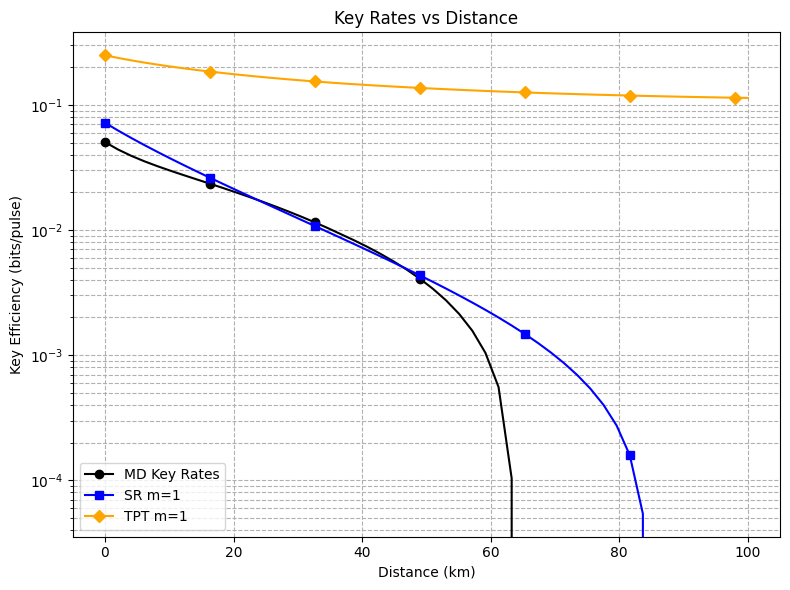

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot Key Rates
ax.plot(distances, MD_key_rates, label='MD Key Rates', marker='o', linestyle='-', color='black', markevery=8)
ax.plot(distances, SR_m1_key_rates, label='SR m=1', marker='s', linestyle='-', color='blue', markevery=8)
ax.plot(distances, TPT_m1_key_rates, label='TPT m=1', marker='D', linestyle='-', color='orange', markevery=8)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Key Efficiency (bits/pulse)')
ax.set_title('Key Rates vs Distance')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', ls='--')

plt.tight_layout()
plt.show()


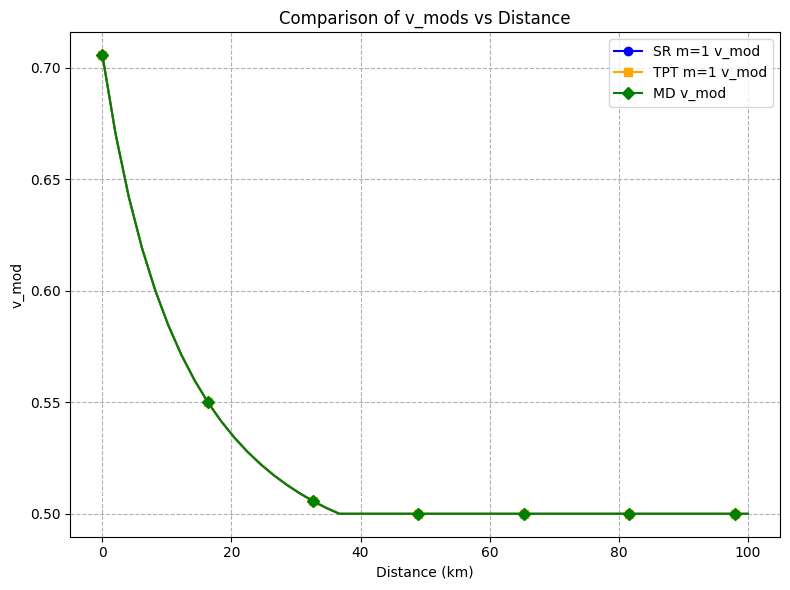

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot v_mods for each method
ax.plot(distances, SR_m1_v_mods, label='SR m=1 v_mod', marker='o', linestyle='-', color='blue', markevery=8)
ax.plot(distances, TPT_m1_v_mods, label='TPT m=1 v_mod', marker='s', linestyle='-', color='orange', markevery=8)
ax.plot(distances, MD_v_mods, label='MD v_mod', marker='D', linestyle='-', color='green', markevery=8)

# Add labels, title, and legend
ax.set_xlabel('Distance (km)')
ax.set_ylabel('v_mod')
ax.set_title('Comparison of v_mods vs Distance')
ax.legend()
ax.grid(True, which='both', ls='--')

plt.tight_layout()
plt.show()

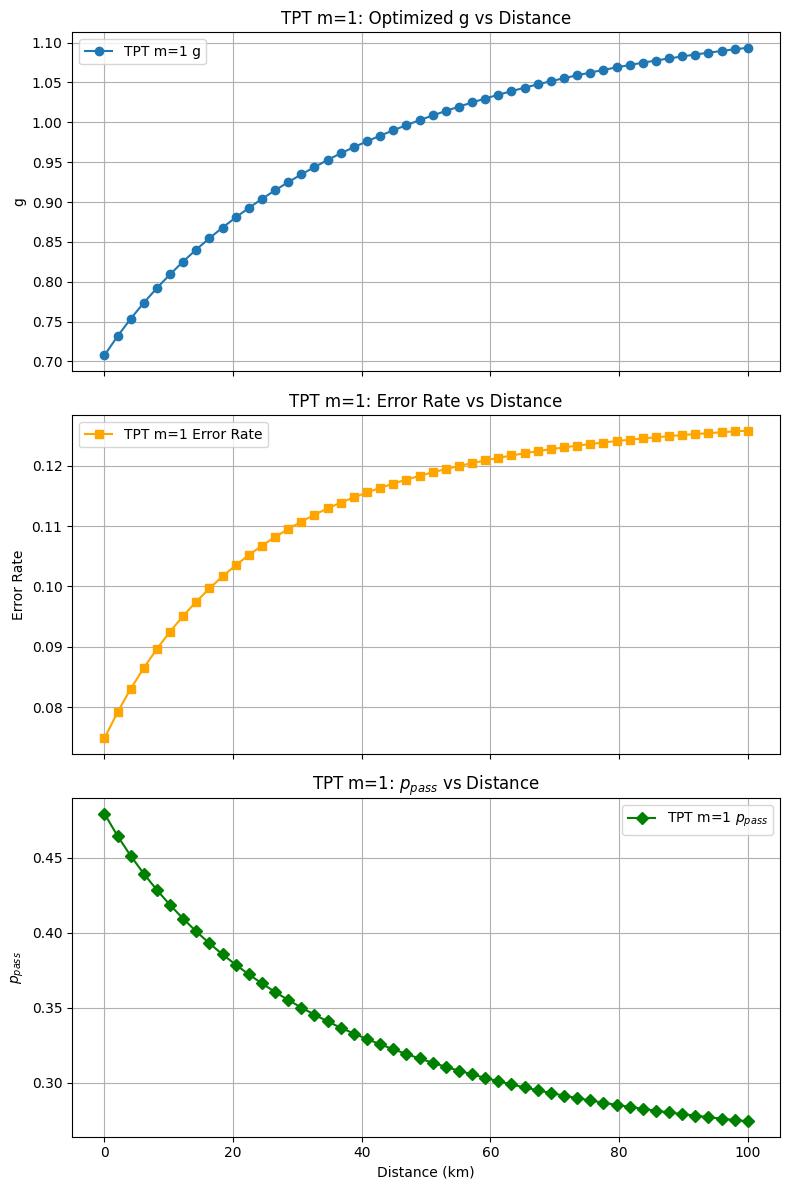

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# Plot TPT m1 g
axs[0].plot(distances, TPT_m1_gs, marker='o', label='TPT m=1 g')
axs[0].set_ylabel('g')
axs[0].set_title('TPT m=1: Optimized g vs Distance')
axs[0].grid(True)
axs[0].legend()

# Plot error rates
axs[1].plot(distances, TPT_m1_error_rates, marker='s', color='orange', label='TPT m=1 Error Rate')
axs[1].set_ylabel('Error Rate')
axs[1].set_title('TPT m=1: Error Rate vs Distance')
axs[1].grid(True)
axs[1].legend()

# Plot p_passes
axs[2].plot(distances, TPT_m1_p_passes, marker='D', color='green', label='TPT m=1 $p_{pass}$')
axs[2].set_xlabel('Distance (km)')
axs[2].set_ylabel('$p_{pass}$')
axs[2].set_title('TPT m=1: $p_{pass}$ vs Distance')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()